In [10]:
import importlib
from RSA_tuner import *
import RSA_nD_tuner
importlib.reload(RSA_nD_tuner)
from RSA_nD_tuner import *


import sys
import os
# Add the directory containing deepsets_classifier.py to the Python path
current_path = os.getcwd()
sys.path.append(os.path.join(current_path, 'classifier'))

from deepsets_classifier import *

In [11]:
class ObservableDataset(Dataset):
	"""
	Converts observable dataset into PyTorch syntax.
	"""
	def __init__(self, data):
		self.data = data

	def __len__(self):
		return self.data.shape[0]

	def __getitem__(self, idx):
		sample = self.data[idx]
		return sample
	
def prescale(exp_data, sim_data, axes=(0, 1)):
    """
    Prescale the experimental and simulated data using the combined mean and standard deviation.

    Args:
        exp_data (np.ndarray): The experimental data.
        sim_data (np.ndarray): The simulated data.
        axes (tuple): The axes along which to calculate the mean and standard deviation.

    Returns:
        np.ndarrays: The prescaled experimental and simulated data.
    """
    # Mask to identify non-padded entries (i.e., entries that are not [0.0, 0.0, 0.0, 0.0])
    non_padded_mask_exp = ~(np.all(exp_data == 0, axis=-1))
    non_padded_mask_sim = ~(np.all(sim_data == 0, axis=-1))
    
    # Flatten the non-padded parts of the datasets along the specified axes for mean/std calculation
    combined_data = np.concatenate([exp_data[non_padded_mask_exp], sim_data[non_padded_mask_sim]], axis=0)
    combined_mean = combined_data.mean(axis=0)
    print("Mean:", combined_mean)
    combined_std = combined_data.std(axis=0)

    # Scale only the non-padded entries using the combined mean and std
    exp_data_scaled = np.copy(exp_data)
    sim_data_scaled = np.copy(sim_data)
    exp_data_scaled[non_padded_mask_exp] = (exp_data[non_padded_mask_exp] - combined_mean) / combined_std
    sim_data_scaled[non_padded_mask_sim] = (sim_data[non_padded_mask_sim] - combined_mean) / combined_std
    
    return exp_data_scaled, sim_data_scaled

In [42]:
# Paths to the datasets
exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.06_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.33_N_1.5e+05_hadrons.npy'
# exp_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.68_b_0.98_sigma_0.335_N_1e4.npy'
sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.5e+05_hadrons.npy'
# sim_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.5e+05_id_mT2_accept_reject_z.npy'
# sim_accept_reject_PATH = '../data/structured_data/pgun_qqbar_mT2_accept_reject_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.5e+05_fPrel.npy'
# sim_fPrel_PATH         = '../data/structured_data/pgun_qqbar_fPrel_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'

# Load the arrays
exp_hadrons       = np.load(exp_hadrons_PATH, mmap_mode="r")
sim_hadrons       = np.load(sim_hadrons_PATH, mmap_mode="r")
sim_accept_reject = np.load(sim_accept_reject_PATH, mmap_mode = "r")
sim_fPrel         = np.load(sim_fPrel_PATH, mmap_mode = "r")

# Print dataset shapes
print('Experimental observable shape:', exp_hadrons.shape)
# print('Experimental observable:', exp_hadrons[0,:]) #the first 10 hadrons and their 5 properties
print('Simulated observable shape:', sim_hadrons.shape)
print('Simulated z shape:', sim_accept_reject.shape)
print('Simulated fPrel shape:', sim_fPrel.shape)

# Restrict to a subset of the full dataset (for memory)
N_events = int(150000)
N = N_events


# Extract the hadron multiplicity
exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N)])
sim_mult = np.array([len(sim_hadrons[i,:][np.abs(sim_hadrons[i,:,0]) > 0.0]) for i in range(N)])

# Find the maximum multiplicity
min_mult = min(exp_mult.min(), sim_mult.min())
max_mult = max(exp_mult.max(), sim_mult.max())
print("Max multiplicity:", max_mult)

# Resize the zero-padding to the maximum multiplicity
exp_hadrons = exp_hadrons[:, :max_mult, :]
sim_hadrons = sim_hadrons[:, :max_mult, :]

# Extract (px, py, pz)
px_exp, py_exp, pz_exp = exp_hadrons[..., 0], exp_hadrons[..., 1], exp_hadrons[..., 2]
px_sim, py_sim, pz_sim = sim_hadrons[..., 0], sim_hadrons[..., 1], sim_hadrons[..., 2]

# Create masks for non-zero momentum entries
mask_exp = (px_exp != 0) | (py_exp != 0) | (pz_exp != 0)
mask_sim = (px_sim != 0) | (py_sim != 0) | (pz_sim != 0)

# Calculate transverse momentum (pT)
pt_exp = np.sqrt(px_exp**2 + py_exp**2)
pt_sim = np.sqrt(px_sim**2 + py_sim**2)

# Initialize arrays for the results with zeros
phi_exp = np.zeros_like(pt_exp)
phi_sim = np.zeros_like(pt_sim)
eta_exp = np.zeros_like(pt_exp)
eta_sim = np.zeros_like(pt_sim)

# Apply the calculations only where the mask is True (non-zero momentum)
phi_exp[mask_exp] = np.arctan2(py_exp[mask_exp], px_exp[mask_exp])
phi_sim[mask_sim] = np.arctan2(py_sim[mask_sim], px_sim[mask_sim])

theta_exp = np.arctan2(pt_exp[mask_exp], pz_exp[mask_exp])
theta_sim = np.arctan2(pt_sim[mask_sim], pz_sim[mask_sim])

eta_exp[mask_exp] = -np.log(np.tan(theta_exp / 2))
eta_sim[mask_sim] = -np.log(np.tan(theta_sim / 2))

# Define the new angular observable array (pT, phi, eta)
exp_obs = np.stack([pt_exp, phi_exp, eta_exp], axis=-1)
sim_obs = np.stack([pt_sim, phi_sim, eta_sim], axis=-1)

# Print dataset shapes
print('Experimental observable shape:', exp_obs.shape)
print('Simulated observable shape:', sim_obs.shape)

# Prescale the data
# N_events = int(10000)
exp_obs, sim_obs = prescale(exp_obs[0:N_events], sim_obs[0:N_events])

# Convert into torch objects
exp_obs = torch.Tensor(exp_obs.copy())
sim_obs = torch.Tensor(sim_obs.copy())

# Define the DeepSets classifier hyperparameters (that match the pre-trained model)
input_dim      = 3
phi_hidden_dim = 32
rho_hidden_dim = 63
phi_layers     = 5
rho_layers     = 3
dropout_prob   = 0.5
mask_pad       = True
device         = 'cpu'

# Initialize the DeepSets classifier
classifier = DeepSetsClassifier(input_dim=input_dim, phi_hidden_dim=phi_hidden_dim, rho_hidden_dim=rho_hidden_dim,
                                phi_layers=phi_layers, rho_layers=rho_layers, device=device,
                                dropout_prob=dropout_prob, mask_pad=mask_pad).to(device)

# Load the pre-trained model
classifier.load_state_dict(torch.load("/pscratch/sd/l/ljpuslar/RSA/RSA/src/classifier/model/deepsets_classifier.pth", map_location=torch.device('cpu')))

# Set to eval mode
classifier.eval()

# Extract the scores
exp_scores = torch.sigmoid(classifier.forward(exp_obs[:N_events], device="cpu")).to(device).detach()
sim_scores = torch.sigmoid(classifier.forward(sim_obs[:N_events], device="cpu")).to(device).detach()


# Convert into torch objects
sim_scores          = torch.Tensor(sim_scores[0:N_events].clone())
sim_accept_reject = torch.Tensor(sim_accept_reject[0:N_events].copy())
sim_fPrel         = torch.Tensor(sim_fPrel[0:N_events].copy())
exp_scores          = torch.Tensor(exp_scores[0:N_events].clone())


# Check the accepted z-values, if z == 1 reduce it by epsilon (a very nasty bug to find).
# The a-coefficient when computing the likelihood has a term proportional to log(1-z). If 
# z = 1, this term diverges to -inf and completely destroys the backward pass.
epsilon = 1e-5
sim_accept_reject[sim_accept_reject == 1] = 1 - epsilon

# Print dataset shapes
print('Experimental scores shape:', exp_scores.shape)
print('Experimental scores:', exp_scores[:10])
print('Simulated scores shape:', sim_scores.shape)
print('Simulated scores:', sim_scores[:10])
print('Simulated z shape:', sim_accept_reject.shape) # only has the z values, accepted and rejected
# print('Simulated z:', sim_accept_reject[0,0,:])
print('Simulated fPrel shape:', sim_fPrel.shape)

# Prepare data for DataLoader
sim_scores        = ObservableDataset(sim_scores)
sim_accept_reject = ObservableDataset(sim_accept_reject)
sim_mT            = ObservableDataset(sim_fPrel)
exp_scores        = ObservableDataset(exp_scores)



Experimental observable shape: (150000, 75, 6)
Simulated observable shape: (150000, 75, 6)
Simulated z shape: (150000, 250, 105)
Simulated fPrel shape: (150000, 250, 100)
Max multiplicity: 25
Experimental observable shape: (150000, 25, 3)
Simulated observable shape: (150000, 25, 3)
Mean: [4.03589079e-01 8.70762243e-04 8.78939656e-01]
Number of learnable parameters: 11671
Experimental scores shape: torch.Size([150000])
Experimental scores: tensor([0.2511, 0.6058, 0.3498, 0.2791, 0.6507, 0.9551, 0.3650, 0.4106, 0.9354,
        0.9069])
Simulated scores shape: torch.Size([150000])
Simulated scores: tensor([0.5232, 0.8207, 0.2655, 0.8811, 0.3727, 0.1253, 0.9098, 0.7861, 0.8570,
        0.8152])
Simulated z shape: torch.Size([150000, 250, 105])
Simulated fPrel shape: torch.Size([150000, 250, 100])


In [43]:
# Set batch size -- set it eqaul to the number of events, we only want one 'batch'
batch_size = 50000
# batch_size = N_events

# Initialize data-loaders
sim_observable_dataloader    = DataLoader(sim_scores,          batch_size = batch_size, shuffle = False)
sim_accept_reject_dataloader = DataLoader(sim_accept_reject, batch_size = batch_size, shuffle = False)
sim_fPrel_dataloader         = DataLoader(sim_fPrel,         batch_size = batch_size, shuffle = False)
exp_observable_dataloader    = DataLoader(exp_scores,          batch_size = batch_size, shuffle = False)

print('Size of sim_observable_dataloader:', len(sim_observable_dataloader.dataset))
print('Size of sim_accept_reject_dataloader:', len(sim_accept_reject_dataloader.dataset))
print('Size of sim_fPrel_dataloader:', len(sim_fPrel_dataloader.dataset))
print('Size of exp_observable_dataloader:', len(exp_observable_dataloader.dataset))
print('Shape of sim_observable_dataloader:', sim_accept_reject_dataloader.dataset.data.shape)


Size of sim_observable_dataloader: 150000
Size of sim_accept_reject_dataloader: 150000
Size of sim_fPrel_dataloader: 150000
Size of exp_observable_dataloader: 150000
Shape of sim_observable_dataloader: torch.Size([150000, 250, 105])


In [44]:
# Training hyperparameters
over_sample_factor = 10.0
# The flow map will be dependent on the learning rate (size of the gradients)
learning_rate = 0.01
fixed_binning = True
# Length of event buffer
dim_multiplicity  = sim_accept_reject_dataloader.dataset.data.shape[1]
dim_accept_reject = sim_accept_reject_dataloader.dataset.data.shape[2]

print('Each event has been zero-padded to a length of', dim_multiplicity)
print('Each emission has been zero-padded to a length of', dim_accept_reject)

# Define base parameters of simulated data (a, b)
aExtraDQuark = 0
aExtraUQuark = 0
aExtraSQuark = 0
aExtraCquark = 0
aExtraBquark = 0
aExtraDiquark = 0.97

bNonstandardD = 0.88
bNonstandardU = 0.88
bNonstandardS = 0.88
bNonstandardC = 0.88
bNonstandardB = 0.88
bNonstandardH = 0.88

aLund = 0.68
bLund = 0.98
sigma_base = 0.335

aLundD = aLund + aExtraDQuark
# bLundD = bNonstandardD
bLundD = bLund
aLundU = aLund + aExtraUQuark
# bLundU = bNonstandardU
bLundU = bLund
aLundS = aLund + aExtraSQuark
# bLundS = bNonstandardS
bLundS = bLund
aLundDiquark = aLund + aExtraDiquark
# bLundDiquark = bNonstandardH
bLundDiquark = bLund


# params_base = {'a0': torch.tensor(aLund), 'b0': torch.tensor(bLund),
params_base = {'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
            'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU), 'b2': torch.tensor(bLundU),
            'a3': torch.tensor(aLundS), 'b3': torch.tensor(bLundS), 'a1103': torch.tensor(aLundDiquark), 'b1103': torch.tensor(bLundDiquark),
            'a2101': torch.tensor(aLundDiquark), 'b2101': torch.tensor(bLundDiquark), 'a2103': torch.tensor(aLundDiquark), 'b2103': torch.tensor(bLundDiquark),
            'a2203': torch.tensor(aLundDiquark), 'b2203': torch.tensor(bLundDiquark), 'a3101': torch.tensor(aLundDiquark), 'b3101': torch.tensor(bLundDiquark),
            'a3103': torch.tensor(aLundDiquark), 'b3103': torch.tensor(bLundDiquark), 'a3201': torch.tensor(aLundDiquark), 'b3201': torch.tensor(bLundDiquark),
            'a3203': torch.tensor(aLundDiquark), 'b3203': torch.tensor(bLundDiquark), 'a3303': torch.tensor(aLundDiquark), 'b3303': torch.tensor(bLundDiquark),
            'sigma': torch.tensor(sigma_base)}

eps = 1e-4
# params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU)}
params_learn = {'a1': torch.tensor(aLundD+eps), 'b1': torch.tensor(bLundD+eps),'sigma': torch.tensor(sigma_base+eps)}
# params_learn = {'a1': torch.tensor(aLundD), 'sigma': torch.tensor(sigma_base)}


# # Define a grid of initial parameters
# ad_range  = (0.5-0.1, 1.5+0.1)#(0.6, 0.80)
# au_range  = (0.5-0.1, 1.5+0.1)#(0.6, 0.80)
# bd_range  = (0.6-0.1, 1.6+0.1)#(0.85, 1.05)

# # Search the whole range of parameters
# a_range  = (0.03, 3.0)#(0.6, 0.80)
# b_range  = (0.2, 2.0)#(0.85, 1.05)

# n_points = 10

Each event has been zero-padded to a length of 250
Each emission has been zero-padded to a length of 105


In [45]:
# Irrelevant parameters for the flow plot that must be initialized for the RSA class
epochs = 100

# # Create an RSA instance
# RSA = RSA_nD_tuner(epochs = epochs, dim_multiplicity = dim_multiplicity, dim_accept_reject = dim_accept_reject, over_sample_factor = over_sample_factor,
# 				params_base = params_base, sim_observable_dataloader = sim_observable_dataloader, sim_z_dataloader = sim_accept_reject_dataloader, 
# 				sim_fPrel_dataloader = sim_fPrel_dataloader, exp_observable_dataloader = exp_observable_dataloader, print_details = False, 
# 				results_dir = "/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flowmap", params_init = params_learn, fixed_binning = True)

print(params_learn)
# Create an RSA instance
RSA = RSA_nD_tuner(epochs = epochs, dim_multiplicity = dim_multiplicity, dim_accept_reject = dim_accept_reject, over_sample_factor = over_sample_factor,
				params_base = params_base, sim_observable_dataloader = sim_observable_dataloader, sim_z_dataloader = sim_accept_reject_dataloader, 
				sim_fPrel_dataloader = sim_fPrel_dataloader, exp_observable_dataloader = exp_observable_dataloader, print_details = True, 
				results_dir = "/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner/jupyter/deepset/Adam_N50k_lr0.01", params_init = params_learn, fixed_binning = True)


{'a1': tensor(0.6801), 'b1': tensor(0.9801), 'sigma': tensor(0.3351)}
BLABLA
A model directory was created at, /pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner/jupyter/deepset/Adam_N50k_lr0.01


In [46]:
# print(a_b_init)
# Set the optimizer
# for i in RSA.weight_nexus.parameters():
#     print(i)

import torch_optimizer as optim

# optimizer = optim.Adahessian(RSA.weight_nexus.parameters())
optimizer = torch.optim.Adam(RSA.weight_nexus.parameters(), lr=0.01)
#optimizer = torch.optim.SGD(macroscopic_trainer.weight_nexus.parameters(), lr=learning_rate)
# Generate gradients
params_final, all_params = RSA.RSA_tune(optimizer)


  0%|                                                                       | 0/100 [00:00<?, ?it/s]

Batch # 0


  0%|                                                                       | 0/100 [03:27<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

points = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner/jupyter/ADAgrad_N50k_3/RSA_tuning_params.npy')
print(np.shape(points))

# points = all_params

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Unpack the three columns
x, y, z = points[:, 0], points[:, 1], points[:, 2]

ax.plot(x, y, z, marker='o', c='blue')  # 3D scatter plot
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter Plot')

plt.tight_layout()
plt.show()


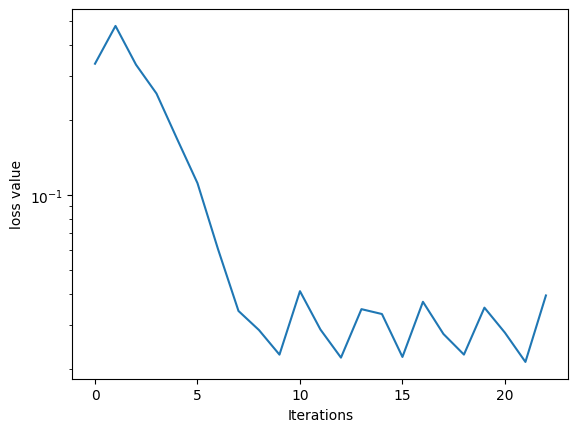

In [4]:
import matplotlib.pyplot as plt
loss = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner/jupyter/ADAgrad_N50k/RSA_tuning_loss.npy')

plt.figure()

plt.plot(loss)
plt.xlabel('Iterations')
plt.ylabel('loss value')
plt.yscale('log')



(38, 3)


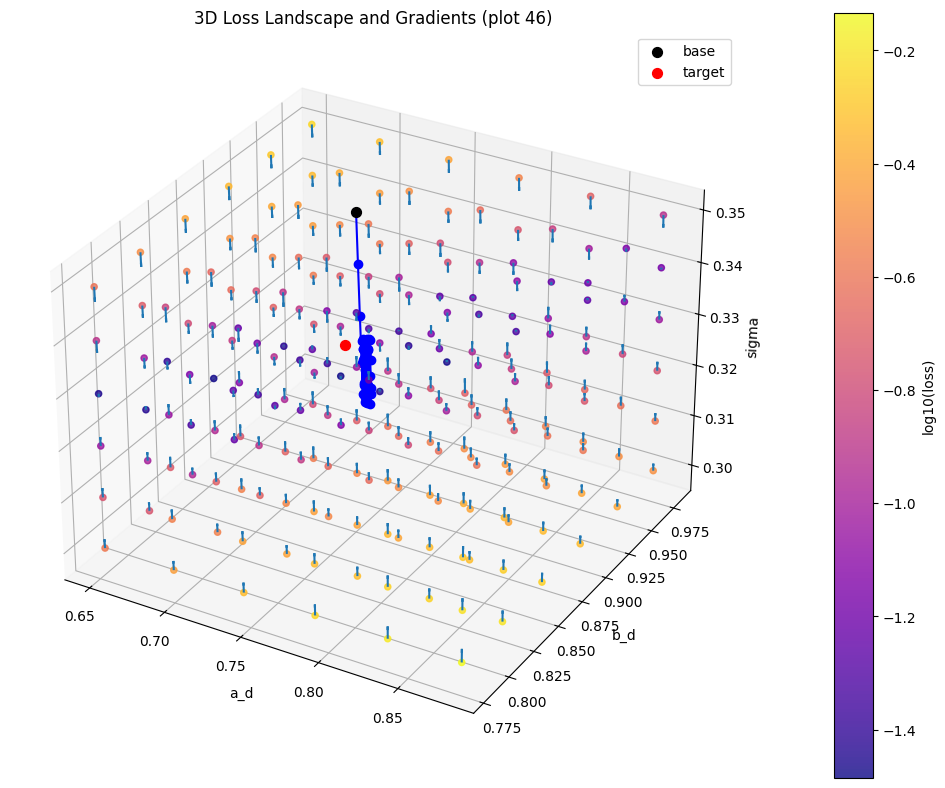

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -- Load data for the chosen plot --
plot_nm = '46'
magnitudes    = np.load(f'temp_results/Flow_map_nD/magnitudes_{plot_nm}.npy')
a_b_gradients = np.load(f'temp_results/Flow_map_nD/gradients_{plot_nm}.npy')
loss_grid     = np.load(f'temp_results/Flow_map_nD/loss_grid_{plot_nm}.npy')
mu_sigmamu    = np.load(f'temp_results/Flow_map_nD/mu_{plot_nm}.npy')
Neff          = np.load(f'temp_results/Flow_map_nD/Neff_{plot_nm}.npy')
mu, sigmamu  = mu_sigmamu[:, 0], mu_sigmamu[:, 1]
a_b_c         = np.load(f'temp_results/Flow_map_nD/ad_bd_sig_{plot_nm}.npy')


# Configuration per plot_nm: scale and base/target points
plot3d_configs = {
    '19': {'scale': 1e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '20': {'scale': 1e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '21': {'scale': 1e4, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '22': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '23': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '24': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '25': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.335)},
    '26': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.325)},
    '27': {'scale': 5e2, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '28': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '29': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '30': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '31': {'scale': 5e2, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '32': {'scale': 5e2, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '33': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.58, 0.88, 0.31)},
    '34': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.33)},
    '35': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.78, 0.88, 0.33)},
    '36': {'scale': 2e4, 'base': (0.68, 0.98, 0.335), 'target': (0.76, 0.98, 0.33)},
    '37': {'scale': 2e4, 'base': (0.68, 0.98, 0.335), 'target': (0.76, 0.98, 0.33)},
    '38': {'scale': 2e4, 'base': (0.68, 0.98, 0.335), 'target': (1.48, 0.98, 0.33)},
    '39': {'scale': 2e4, 'base': (0.68, 0.98, 0.335), 'target': (1.48, 0.98, 0.33)},
    '40': {'scale': 8e2, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '41': {'scale': 2e4, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '42': {'scale': 8e2, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '43': {'scale': 8e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '44': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '45': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '46': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
    '47': {'scale': 5e3, 'base': (0.68, 0.98, 0.335), 'target': (0.74, 0.88, 0.33)},
}
config = plot3d_configs.get(plot_nm)
if config is None:
    raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# Unpack coordinates and gradients
ad, bd, sig = a_b_c[:, 0], a_b_c[:, 1], a_b_c[:, 2]
g1, g2, g3  = -a_b_gradients[:, 0], -a_b_gradients[:, 1], -a_b_gradients[:, 2]

# Unpack tuner values
# points = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner/jupyter/ADAgrad_N50k_5/RSA_tuning_params.npy')
points = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner/jupyter/RSA_tuning_params_SGD_lr_0.001.npy')

# Unpack the three columns
x, y, z = points[:, 0], points[:, 1], points[:, 2]




# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')



# Plot base and target
ax.scatter(*config['base'],  marker='o', color='black', s=50, label='base')
ax.scatter(*config['target'], marker='o', color='red',   s=50, label='target')
ax.plot(x, y, z, marker='o', c='blue')  # 3D scatter plot

# Quiver for gradient field
ax.quiver(ad, bd, sig,
          g1 / config['scale'],
          g2 / config['scale'],
          g3 / config['scale'],
          length=1.0, normalize=False)

# Scatter colored by loss value
sc = ax.scatter(ad, bd, sig,
                c=np.log10(loss_grid), cmap='plasma',
                s=20, alpha=0.8)
cbar = fig.colorbar(sc, pad=0.1)
cbar.set_label('log10(loss)')

# Labels and legend
ax.set_xlabel('a_d')
ax.set_ylabel('b_d')
ax.set_zlabel('sigma')
ax.set_title(f'3D Loss Landscape and Gradients (plot {plot_nm})')
ax.legend()
plt.tight_layout()
plt.show()